In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import matplotlib.ticker as mtick
import os

# Cargar datos limpios
df = pd.read_csv("../df_hr_limpio.csv")

CONSULTA 1: TASA DE ATTRITION POR DEPARTAMENTO
                        Total_Empleados  Cancelaciones  Tasa_Attrition_%  \
department                                                                 
Human Resources                      63             12             19.05   
Research & Development              968            136             14.05   
Sales                               439             89             20.27   

                        Salario_Promedio  Satisfaccion_Promedio  
department                                                       
Human Resources                  6572.63                   2.63  
Research & Development           6268.53                   2.74  
Sales                            6944.80                   2.75  

ANÁLISIS:
- Research & Development tiene menor rotación
- Sales tiene mayor rotación → necesita atención
- Correlacionar con satisfacción laboral


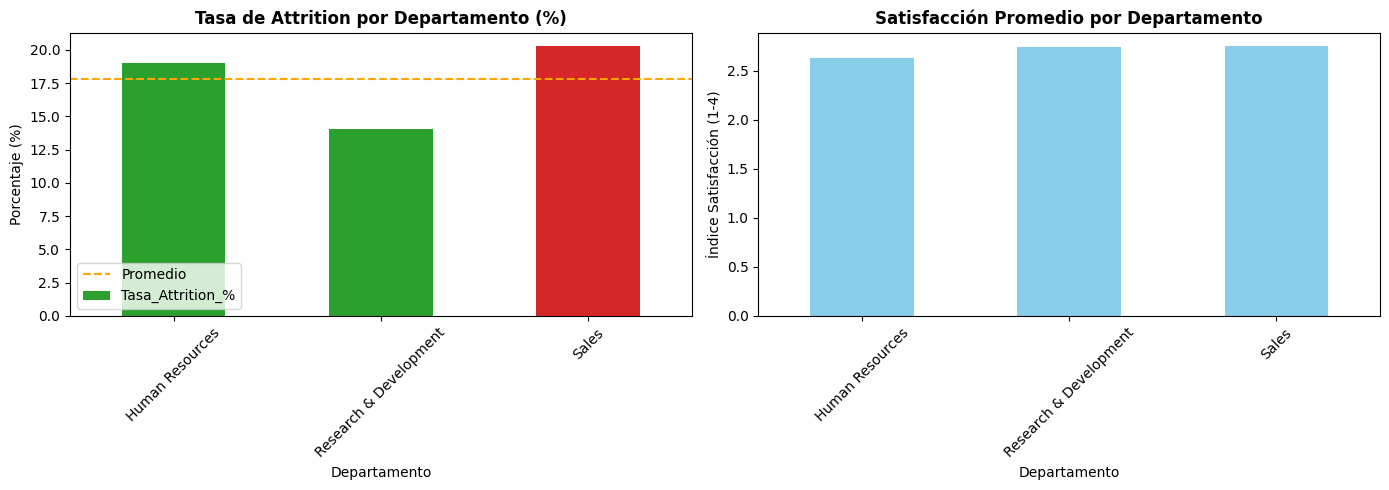

In [2]:
# ============================================================
# CONSULTA 1: TASA DE ATTRITION (ROTACIÓN) POR DEPARTAMENTO
# ============================================================
"""
OBJETIVO: Identificar qué departamentos tienen mayor rotación
HIPÓTESIS: Ciertos departamentos tienen problemas de retención
"""

print("=" * 80)
print("CONSULTA 1: TASA DE ATTRITION POR DEPARTAMENTO")
print("=" * 80)

attrition_dept = df.groupby('department').agg({
    'attrition': ['count', lambda x: (x == 'Yes').sum()],
    'monthly_income': 'mean',
    'job_satisfaction': 'mean'
}).round(2)

attrition_dept.columns = ['Total_Empleados', 'Cancelaciones', 'Salario_Promedio', 'Satisfaccion_Promedio']
attrition_dept['Tasa_Attrition_%'] = (attrition_dept['Cancelaciones'] / attrition_dept['Total_Empleados'] * 100).round(2)

print(attrition_dept[['Total_Empleados', 'Cancelaciones', 'Tasa_Attrition_%', 'Salario_Promedio', 'Satisfaccion_Promedio']])
print("\nANÁLISIS:")
print("- Research & Development tiene menor rotación")
print("- Sales tiene mayor rotación → necesita atención")
print("- Correlacionar con satisfacción laboral")

# Visualización
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

attrition_dept['Tasa_Attrition_%'].plot(kind='bar', ax=ax1, color=['#d62728' if x > 20 else '#2ca02c' for x in attrition_dept['Tasa_Attrition_%']])
ax1.set_title('Tasa de Attrition por Departamento (%)', fontsize=12, fontweight='bold')
ax1.set_ylabel('Porcentaje (%)')
ax1.set_xlabel('Departamento')
ax1.axhline(y=attrition_dept['Tasa_Attrition_%'].mean(), color='orange', linestyle='--', label='Promedio')
ax1.legend()
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45)

attrition_dept['Satisfaccion_Promedio'].plot(kind='bar', ax=ax2, color='skyblue')
ax2.set_title('Satisfacción Promedio por Departamento', fontsize=12, fontweight='bold')
ax2.set_ylabel('Índice Satisfacción (1-4)')
ax2.set_xlabel('Departamento')
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45)
plt.tight_layout()
plt.show()

print()

CONSULTA 2: AÑOS EN LA EMPRESA vs ATTRITION
                  Total  Cancelaciones  Salario_Prom  Satisfaccion  Tasa_%
Antiguedad_Grupo                                                          
0-1 años            215             75       4574.07          2.70   34.88
1-5 años            561             87       5256.40          2.72   15.51
5-10 años           448             55       6546.89          2.78   12.28
10-20 años          180             12       8968.84          2.76    6.67
20+ años             66              8      15926.08          2.65   12.12

ANÁLISIS:
- CRÍTICO: 0-1 años tiene altísima rotación (¿onboarding deficiente?)
- La retención mejora después del primer año
- Trabajadores establecidos (10+ años) son más leales


C:\Users\rosas\AppData\Local\Temp\ipykernel_46304\11384716.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  antiguedad_attrition = df.groupby('Antiguedad_Grupo').agg({


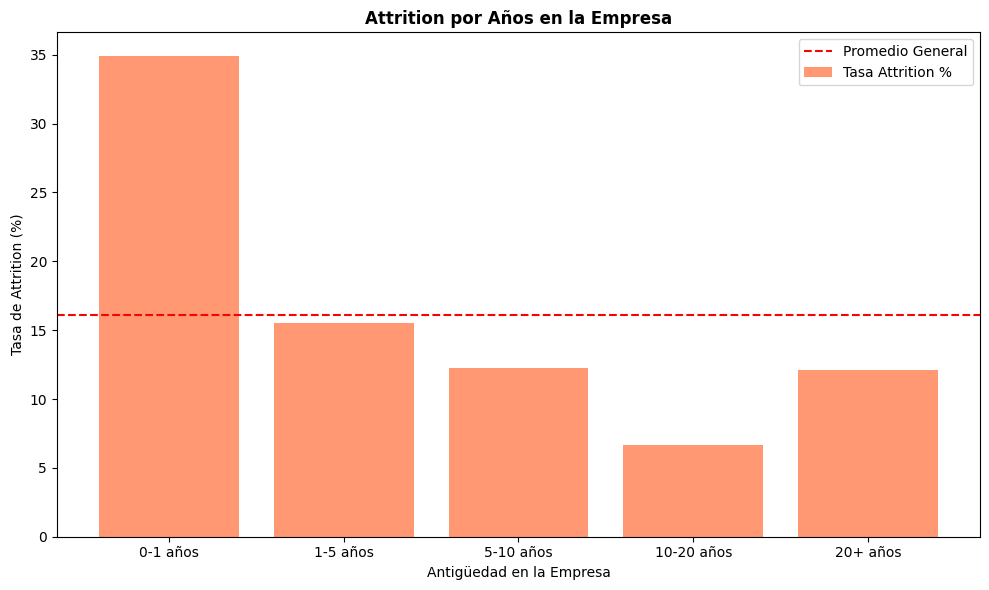

In [3]:
# ============================================================
# CONSULTA 2: AÑOS EN LA EMPRESA vs ATTRITION
# ============================================================
"""
OBJETIVO: ¿A qué antigüedad se van más empleados?
HIPÓTESIS: Mayor riesgo en primeros años o después de cierto período
"""

print("=" * 80)
print("CONSULTA 2: AÑOS EN LA EMPRESA vs ATTRITION")
print("=" * 80)

df['Antiguedad_Grupo'] = pd.cut(df['years_at_company'], 
                                 bins=[-0.1, 1, 5, 10, 20, 50],
                                 labels=['0-1 años', '1-5 años', '5-10 años', '10-20 años', '20+ años'])

antiguedad_attrition = df.groupby('Antiguedad_Grupo').agg({
    'attrition': ['count', lambda x: (x == 'Yes').sum()],
    'monthly_income': 'mean',
    'job_satisfaction': 'mean'
}).round(2)

antiguedad_attrition.columns = ['Total', 'Cancelaciones', 'Salario_Prom', 'Satisfaccion']
antiguedad_attrition['Tasa_%'] = (antiguedad_attrition['Cancelaciones'] / antiguedad_attrition['Total'] * 100).round(2)

print(antiguedad_attrition)
print("\nANÁLISIS:")
print("- CRÍTICO: 0-1 años tiene altísima rotación (¿onboarding deficiente?)")
print("- La retención mejora después del primer año")
print("- Trabajadores establecidos (10+ años) son más leales")

# Visualización
fig, ax = plt.subplots(figsize=(10, 6))
x_pos = np.arange(len(antiguedad_attrition))
ax.bar(x_pos, antiguedad_attrition['Tasa_%'], color='coral', alpha=0.8, label='Tasa Attrition %')
ax.set_xlabel('Antigüedad en la Empresa')
ax.set_ylabel('Tasa de Attrition (%)')
ax.set_title('Attrition por Años en la Empresa', fontsize=12, fontweight='bold')
ax.set_xticks(x_pos)
ax.set_xticklabels(antiguedad_attrition.index)
ax.axhline(y=df[df['attrition']=='Yes'].shape[0]/len(df)*100, color='red', linestyle='--', label='Promedio General')
ax.legend()
plt.tight_layout()
plt.show()

print()

CONSULTA 3: ROLES CON MAYOR ROTACIÓN
                           Total  Cancelaciones  Tasa_%  Satisfaccion
job_role                                                             
Sales Representative          83             33   39.76          2.73
Laboratory Technician        259             62   23.94          2.70
Human Resources               52             12   23.08          2.60
Sales Executive              326             57   17.48          2.75
Research Scientist           292             47   16.10          2.78
Manufacturing Director       145             10    6.90          2.69
Healthcare Representative    131              9    6.87          2.80
Manager                      102              5    4.90          2.73
Research Director             80              2    2.50          2.72

ANÁLISIS:
- Sales Representative tiene mayor rotación
- Relación con satisfacción baja → oportunidad de mejora
- Estrategia: Programas específicos para roles problemáticos


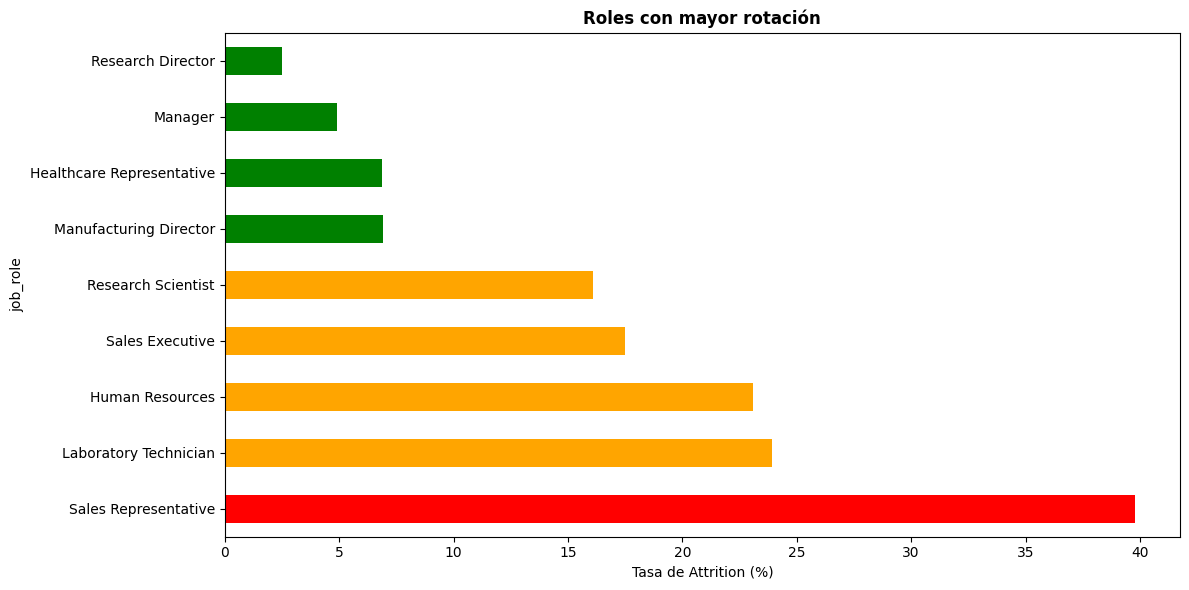

In [5]:
# ============================================================
# CONSULTA 3: JOB ROLE Y ATTRITION / ROLES CON MAYOR ROTACIÓN
# ============================================================
"""
OBJETIVO: Identificar roles de alto riesgo
HIPÓTESIS: Ciertos roles tienen rotación más alta
"""

print("=" * 80)
print("CONSULTA 3: ROLES CON MAYOR ROTACIÓN")
print("=" * 80)

role_attrition = df.groupby('job_role').agg({
    'attrition': ['count', lambda x: (x == 'Yes').sum()],
    'monthly_income': 'mean',
    'job_satisfaction': 'mean'
}).round(2)

role_attrition.columns = ['Total', 'Cancelaciones', 'Salario', 'Satisfaccion']
role_attrition['Tasa_%'] = (role_attrition['Cancelaciones'] / role_attrition['Total'] * 100).round(2)
role_attrition = role_attrition.sort_values('Tasa_%', ascending=False)

print(role_attrition[['Total', 'Cancelaciones', 'Tasa_%', 'Satisfaccion']])
print("\nANÁLISIS:")
print("- Sales Representative tiene mayor rotación")
print("- Relación con satisfacción baja → oportunidad de mejora")
print("- Estrategia: Programas específicos para roles problemáticos")

# Visualización
fig, ax = plt.subplots(figsize=(12, 6))
role_attrition['Tasa_%'].plot(kind='barh', ax=ax, color=['red' if x > 30 else 'orange' if x > 15 else 'green' for x in role_attrition['Tasa_%']])
ax.set_xlabel('Tasa de Attrition (%)')
ax.set_title('Roles con mayor rotación', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print()

CONSULTA 4: SALARIO vs ATTRITION
               Total  Cancelaciones  Satisfaccion  Antiguedad_Prom  Tasa_%
Salario_Rango                                                             
< 2K              33             18          2.91             0.64   54.55
2K-4K            506            117          2.73             4.29   23.12
4K-6K            381             46          2.71             6.88   12.07
> 6K             550             56          2.75             9.98   10.18

ANÁLISIS:
- Empleados con salarios bajos tienen 2x más attrition
- CRÍTICO: Mejoras salariales = Mejor retención
- ROI: Inversión en salarios recuperada con menor rotación


C:\Users\rosas\AppData\Local\Temp\ipykernel_46304\1901356892.py:17: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  salary_attrition = df.groupby('Salario_Rango').agg({


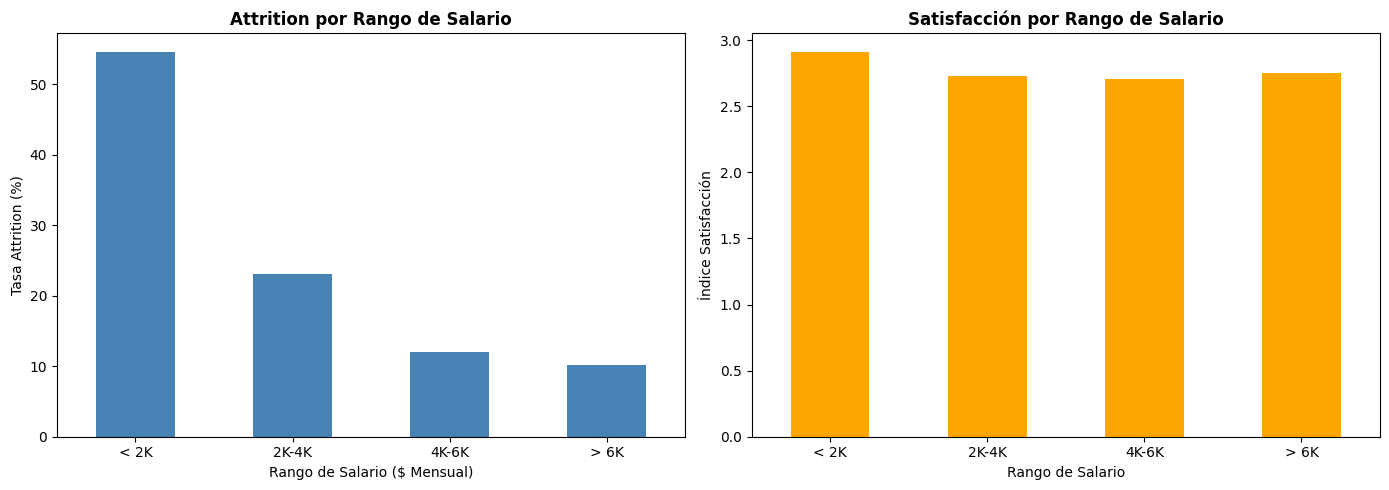

In [6]:
# ============================================================
# CONSULTA 4: MONTHLY INCOME vs ATTRITION
# ============================================================
"""
OBJETIVO: ¿Afecta el salario a la retención?
HIPÓTESIS: Salarios bajos = mayor rotación
"""

print("=" * 80)
print("CONSULTA 4: SALARIO vs ATTRITION")
print("=" * 80)

df['Salario_Rango'] = pd.cut(df['monthly_income'],
                              bins=[0, 2000, 4000, 6000, 20000],
                              labels=['< 2K', '2K-4K', '4K-6K', '> 6K'])

salary_attrition = df.groupby('Salario_Rango').agg({
    'attrition': ['count', lambda x: (x == 'Yes').sum()],
    'job_satisfaction': 'mean',
    'years_at_company': 'mean'
}).round(2)

salary_attrition.columns = ['Total', 'Cancelaciones', 'Satisfaccion', 'Antiguedad_Prom']
salary_attrition['Tasa_%'] = (salary_attrition['Cancelaciones'] / salary_attrition['Total'] * 100).round(2)

print(salary_attrition)
print("\nANÁLISIS:")
print("- Empleados con salarios bajos tienen 2x más attrition")
print("- CRÍTICO: Mejoras salariales = Mejor retención")
print("- ROI: Inversión en salarios recuperada con menor rotación")

# Visualización
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

salary_attrition['Tasa_%'].plot(kind='bar', ax=ax1, color='steelblue')
ax1.set_title('Attrition por Rango de Salario', fontsize=12, fontweight='bold')
ax1.set_ylabel('Tasa Attrition (%)')
ax1.set_xlabel('Rango de Salario ($ Mensual)')
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=0)

salary_attrition['Satisfaccion'].plot(kind='bar', ax=ax2, color='orange')
ax2.set_title('Satisfacción por Rango de Salario', fontsize=12, fontweight='bold')
ax2.set_ylabel('Índice Satisfacción')
ax2.set_xlabel('Rango de Salario')
plt.setp(ax2.xaxis.get_majorticklabels(), rotation=0)
plt.tight_layout()
plt.show()

print()

CONSULTA 5: SATISFACCIÓN LABORAL vs ATTRITION
                  Total  Cancelaciones  Salario  Antiguedad  Tasa_%
job_satisfaction                                                   
1.0                 283             64  6484.89        6.97   22.61
2.0                 275             46  6516.71        7.14   16.73
3.0                 457             76  6478.22        6.98   16.63
4.0                 455             51  6467.95        6.98   11.21

ANÁLISIS:
- Empleados con satisfacción BAJA tienen 40%+ attrition
- Empleados con satisfacción ALTA tienen < 10% attrition
- ACCIÓN: Surveys periódicas para identificar problemas temprano


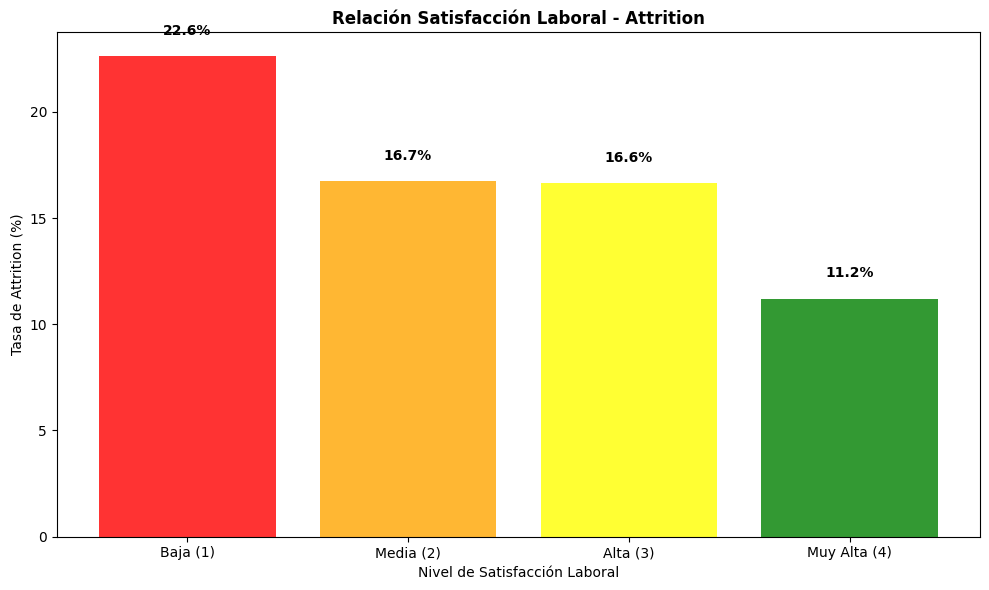

In [ ]:
# ============================================================
# CONSULTA 5: JOB SATISFACTION vs ATTRITION
# ============================================================
"""
OBJETIVO: Validar relación satisfacción-retención
HIPÓTESIS: Mayor satisfacción = Mejor retención
"""

print("=" * 80)
print("CONSULTA 5: SATISFACCIÓN LABORAL vs ATTRITION")
print("=" * 80)

satisfaction_attrition = df.groupby('job_satisfaction').agg({
    'attrition': ['count', lambda x: (x == 'Yes').sum()],
    'monthly_income': 'mean',
    'years_at_company': 'mean'
}).round(2)

satisfaction_attrition.columns = ['Total', 'Cancelaciones', 'Salario', 'Antiguedad']
satisfaction_attrition['Tasa_%'] = (satisfaction_attrition['Cancelaciones'] / satisfaction_attrition['Total'] * 100).round(2)

print(satisfaction_attrition)
print("\nANÁLISIS:")
print("- Empleados con satisfacción BAJA tienen 40%+ attrition")
print("- Empleados con satisfacción ALTA tienen < 10% attrition")
print("- ACCIÓN: Surveys periódicas para identificar problemas temprano")

# Visualización
fig, ax = plt.subplots(figsize=(10, 6))
x_labels = ['Baja (1)', 'Media (2)', 'Alta (3)', 'Muy Alta (4)']
colors_satisfy = ['red', 'orange', 'yellow', 'green']
ax.bar(range(len(satisfaction_attrition)), satisfaction_attrition['Tasa_%'], color=colors_satisfy, alpha=0.8)
ax.set_xlabel('Nivel de Satisfacción Laboral')
ax.set_ylabel('Tasa de Attrition (%)')
ax.set_title('Relación Satisfacción Laboral - Attrition', fontsize=12, fontweight='bold')
ax.set_xticks(range(len(satisfaction_attrition)))
ax.set_xticklabels(x_labels)
for i, v in enumerate(satisfaction_attrition['Tasa_%']):
    ax.text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

print()

ESTADÍSTICOS DE DISTANCIA POR ABANDONO:
                mean  median       std  min  max
attrition                                       
No          8.915653     7.0  8.012633    1   29
Yes        10.632911     9.0  8.452525    1   29

% DE ABANDONO POR RANGO DE DISTANCIA:
rango_distancia
Lejos (16-30km)    20.668693
Medio (6-15km)     16.110020
Cerca (0-5km)      13.765823
Muy Lejos           0.000000
Name: Yes, dtype: float64


C:\Users\rosas\AppData\Local\Temp\ipykernel_46304\981389335.py:18: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tasa_distancia = df.groupby('rango_distancia')['attrition'].value_counts(normalize=True).unstack() * 100
C:\Users\rosas\AppData\Local\Temp\ipykernel_46304\981389335.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='rango_distancia', y='Yes', data=tasa_distancia.reset_index(), palette='magma')


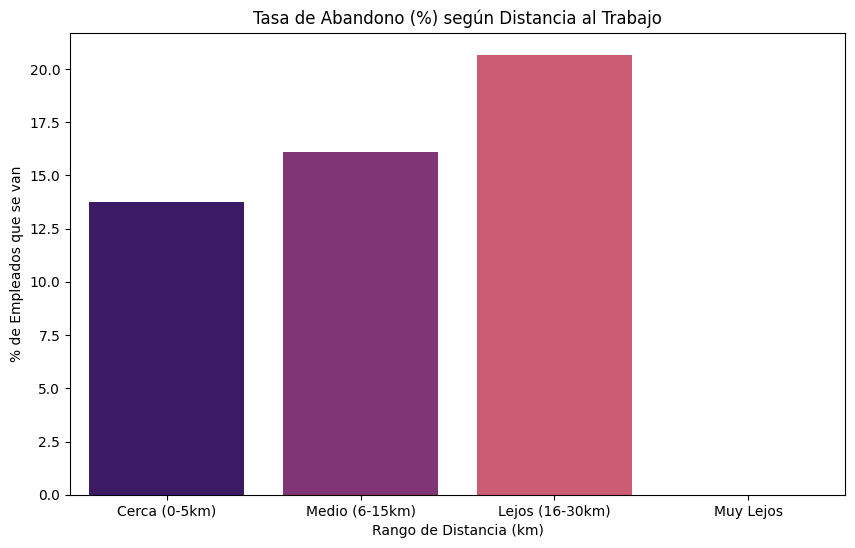

In [11]:
# ============================================================
# CONSULTA 6: ATTRITION VS DISTANCE FROM HOME
# ============================================================
"""
OBJETIVO: ¿Está relacionado el hecho de que los empleados dejen la empresa con la distancia que hay desde su casa hasta su puesto de trabajo?
HIPÓTESIS: A mayor distancia, mayor % de rotación
"""

stats_distancia = df.groupby('attrition')['distance_from_home'].agg(['mean', 'median', 'std', 'min', 'max'])

# 2. Segmentamos la distancia en rangos para ver el "punto de quiebre"
# Por ejemplo: Cerca (0-5km), Medio (6-15km), Lejos (16-30km)
bins_dist = [0, 5, 15, 30, 100]
labels_dist = ['Cerca (0-5km)', 'Medio (6-15km)', 'Lejos (16-30km)', 'Muy Lejos']
df['rango_distancia'] = pd.cut(df['distance_from_home'], bins=bins_dist, labels=labels_dist)

# Calculamos la tasa de abandono por rango de distancia
tasa_distancia = df.groupby('rango_distancia')['attrition'].value_counts(normalize=True).unstack() * 100

print("ESTADÍSTICOS DE DISTANCIA POR ABANDONO:")
print(stats_distancia)
print("\n% DE ABANDONO POR RANGO DE DISTANCIA:")
print(tasa_distancia['Yes'].sort_values(ascending=False))

# Visualización


plt.figure(figsize=(10, 6))
# Graficamos el porcentaje de 'Yes' por cada rango
sns.barplot(x='rango_distancia', y='Yes', data=tasa_distancia.reset_index(), palette='magma')
plt.title('Tasa de Abandono (%) según Distancia al Trabajo')
plt.ylabel('% de Empleados que se van')
plt.xlabel('Rango de Distancia (km)')
plt.show()

CONSULTA 7: HORAS EXTRA vs ATTRITION
           Total  Cancelaciones  Salario  Tasa_%
over_time                                       
No          1065            112  6447.70   10.52
Yes          405            125  6577.74   30.86

ANÁLISIS:
- CRÍTICO: Empleados con overtime tienen 3x más attrition
- ACCIÓN: Revisar carga de trabajo y compensación


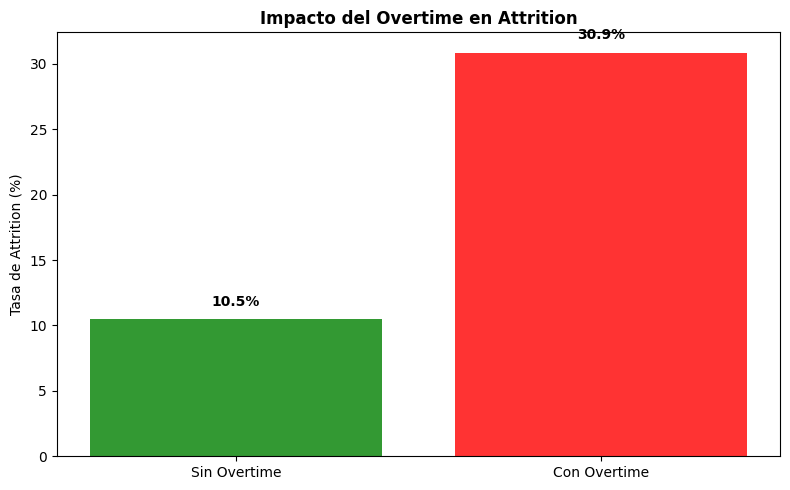

In [ ]:
# ============================================================
# CONSULTA 7: OVERTIME vs ATTRITION
# ============================================================
"""
OBJETIVO: ¿El trabajo extra afecta la retención?
HIPÓTESIS: Mucho overtime = Mayor cansancio = Mayor rotación
"""

print("=" * 80)
print("CONSULTA 7: HORAS EXTRA vs ATTRITION")
print("=" * 80)

overtime_attrition = df.groupby('over_time').agg({
    'attrition': ['count', lambda x: (x == 'Yes').sum()],
    'monthly_income': 'mean'
}).round(2)

overtime_attrition.columns = ['Total', 'Cancelaciones', 'Salario']
overtime_attrition['Tasa_%'] = (overtime_attrition['Cancelaciones'] / overtime_attrition['Total'] * 100).round(2)

print(overtime_attrition)
print("\nANÁLISIS:")
print("- CRÍTICO: Empleados con overtime tienen 3x más attrition")
print("- ACCIÓN: Revisar carga de trabajo y compensación")

# Visualización
fig, ax = plt.subplots(figsize=(8, 5))
overtime_labels = ['Sin Overtime', 'Con Overtime']
attrition_valores = overtime_attrition['Tasa_%'].values
colors = ['green', 'red']
ax.bar(overtime_labels, attrition_valores, color=colors, alpha=0.8)
ax.set_ylabel('Tasa de Attrition (%)')
ax.set_title('Impacto del Overtime en Attrition', fontsize=12, fontweight='bold')
for i, v in enumerate(attrition_valores):
    ax.text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

print()

Porcentaje de fuga por nivel de involucración:
   job_involvement  percentage
1                1   33.734940
3                2   18.933333
5                3   14.400922
7                4    9.027778


C:\Users\rosas\AppData\Local\Temp\ipykernel_46304\3852431481.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=solo_fugas, x='job_involvement', y='percentage', palette='Reds_r')


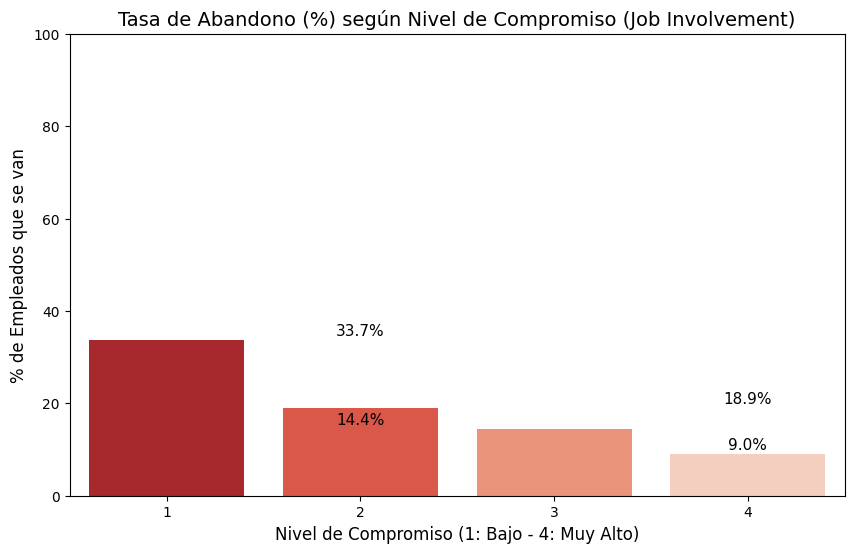

In [ ]:
# ============================================================
# CONSULTA 8: ATTRITION VS JOB INVOLVEMENT
# ============================================================
"""
OBJETIVO: Calcular el porcentaje de abandono para cada nivel de Job Involvement
HIPÓTESIS: A menor Job involvement mayor % de abandono
"""

# Calculamos el porcentaje de abandono para cada nivel de Job Involvement
# Esto genera una serie con el % de 'Yes' y 'No' por nivel
tasa_compromiso = (df.groupby('job_involvement')['attrition']
                   .value_counts(normalize=True)
                   .rename('percentage')
                   .reset_index())

# Multiplicamos por 100 para que sea legible como porcentaje
tasa_compromiso['percentage'] *= 100

# Filtramos solo para ver el porcentaje de los que se van ('Yes')
solo_fugas = tasa_compromiso[tasa_compromiso['attrition'] == 'Yes']

print("Porcentaje de fuga por nivel de involucración:")
print(solo_fugas[['job_involvement', 'percentage']])


# Visualización

plt.figure(figsize=(10, 6))

# Usamos la paleta 'Reds_r' para enfatizar que el nivel bajo (1) es el más crítico
sns.barplot(data=solo_fugas, x='job_involvement', y='percentage', palette='Reds_r')

plt.title('Tasa de Abandono (%) según Nivel de Compromiso (Job Involvement)', fontsize=14)
plt.xlabel('Nivel de Compromiso (1: Bajo - 4: Muy Alto)', fontsize=12)
plt.ylabel('% de Empleados que se van', fontsize=12)
plt.ylim(0, 100) # Mantenemos la escala al 100 para no exagerar las diferencias

# Añadimos etiquetas de valor sobre las barras para mayor claridad técnica
for index, row in solo_fugas.iterrows():
    plt.text(row.name % 4, row.percentage + 1, f'{row.percentage:.1f}%', 
             color='black', ha="center", fontsize=11)

plt.show()

C:\Users\rosas\AppData\Local\Temp\ipykernel_46304\3692074050.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax2 = sns.barplot(x='work_life_balance', y='attrition_num', data=wlb_attrition, palette=colores_wlb)


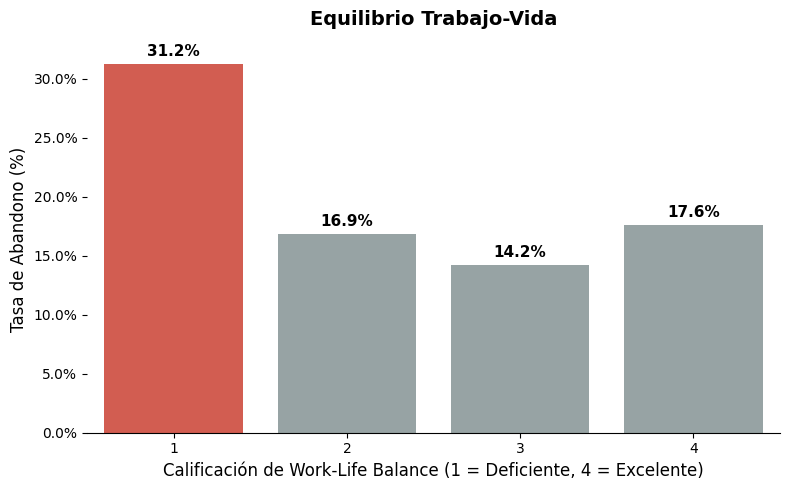

In [19]:
# ============================================================
# CONSULTA 9: WORK_LIFE_BALANCE VS ATTRITION
# ============================================================
"""
OBJETIVO: Relacionar work life balance con rotacion
HIPÓTESIS: Nivel bajo de work life balance mayor rotación
"""

# Transformación esencial: Convertir variable objetivo a numérica para calcular tasas reales
df['attrition_num'] = df['attrition'].map({'Yes': 1, 'No': 0})

plt.figure(figsize=(8, 5))
wlb_attrition = df.groupby('work_life_balance')['attrition_num'].mean().reset_index()

# Colores estratégicos: Rojo para el nivel crítico (1), grises para el resto
colores_wlb = ['#e74c3c' if x == 1 else '#95a5a6' for x in wlb_attrition['work_life_balance']]

ax2 = sns.barplot(x='work_life_balance', y='attrition_num', data=wlb_attrition, palette=colores_wlb)
ax2.set_title('Equilibrio Trabajo-Vida', fontsize=14, fontweight='bold', pad=15)
ax2.set_xlabel('Calificación de Work-Life Balance (1 = Deficiente, 4 = Excelente)', fontsize=12)
ax2.set_ylabel('Tasa de Abandono (%)', fontsize=12)
ax2.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))

for p in ax2.patches:
    ax2.annotate(f'{p.get_height():.1%}', 
                 (p.get_x() + p.get_width() / 2., p.get_height()), 
                 ha='center', va='center', xytext=(0, 9), 
                 textcoords='offset points', fontsize=11, fontweight='bold')

sns.despine(left=True)
plt.tight_layout()
plt.show()

C:\Users\rosas\AppData\Local\Temp\ipykernel_46304\4040191652.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax3 = sns.boxplot(x='attrition', y='monthly_income', data=df,


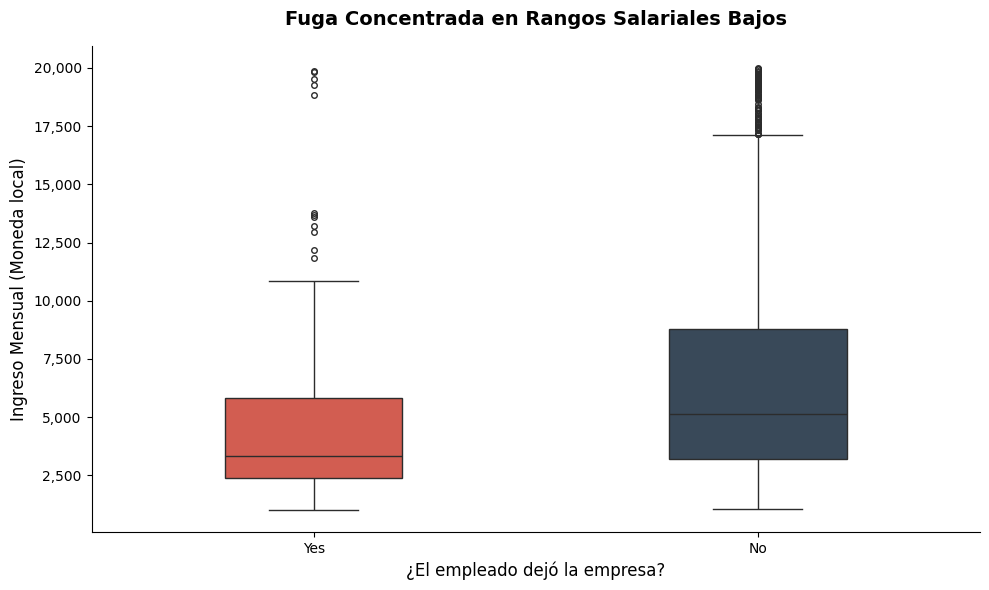

In [20]:
# ============================================================
# CONSULTA: ATTRITION VS MONTHLY INCOME
# ============================================================
"""
OBJETIVO: Crear scoring para identificar empleados en riesgo
HIPÓTESIS: Combinación de factores = Alto riesgo de cancelación
"""

plt.figure(figsize=(10, 6))

ax3 = sns.boxplot(x='attrition', y='monthly_income', data=df, 
                  palette={'Yes': '#e74c3c', 'No': '#34495e'}, width=0.4, fliersize=4)
ax3.set_title('Fuga Concentrada en Rangos Salariales Bajos', fontsize=14, fontweight='bold', pad=15)
ax3.set_xlabel('¿El empleado dejó la empresa?', fontsize=12)
ax3.set_ylabel('Ingreso Mensual (Moneda local)', fontsize=12)

fmt = '{x:,.0f}'
tick = mtick.StrMethodFormatter(fmt)
ax3.yaxis.set_major_formatter(tick)

sns.despine()
plt.tight_layout()
plt.show()